# Spotify Music Genre Classification

This notebook performs Music Genre Classification using Spotify data.
We use numerical audio features like danceability, energy, tempo, loudness, etc.
The target is the music genre. We will:

1. Load and preprocess data
2. Perform exploratory data analysis (EDA)
3. Build a Neural Network using Keras + TensorFlow
4. Train and evaluate the model
5. Save model and predictions


In [2]:
#import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix


import pandas as pd
import numpy as np
import tensorflow as tf
print(pd.__version__, np.__version__, tf.__version__)

2.3.3 2.2.6 2.20.0


In [4]:
#load dataset
df = pd.read_csv(r'D:\MoodMate\data\spotify_data.csv')

# Show first 5 rows
df.head()


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [5]:
#Cleaning

# Dataset summary
df.info()

# Check missing values
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  object 
 1   artist_name       232725 non-null  object 
 2   track_name        232724 non-null  object 
 3   track_id          232725 non-null  object 
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  object 
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  object 
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  time_signature    23

In [6]:
#Data PreProcessing

# Keeping only numeric features for model
numeric_features = df.select_dtypes(include=np.number).columns.tolist()
print("Numeric features:", numeric_features)

X = df[numeric_features]
y = df['genre']

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_categorical, test_size=0.2, random_state=42
)


Numeric features: ['popularity', 'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence']


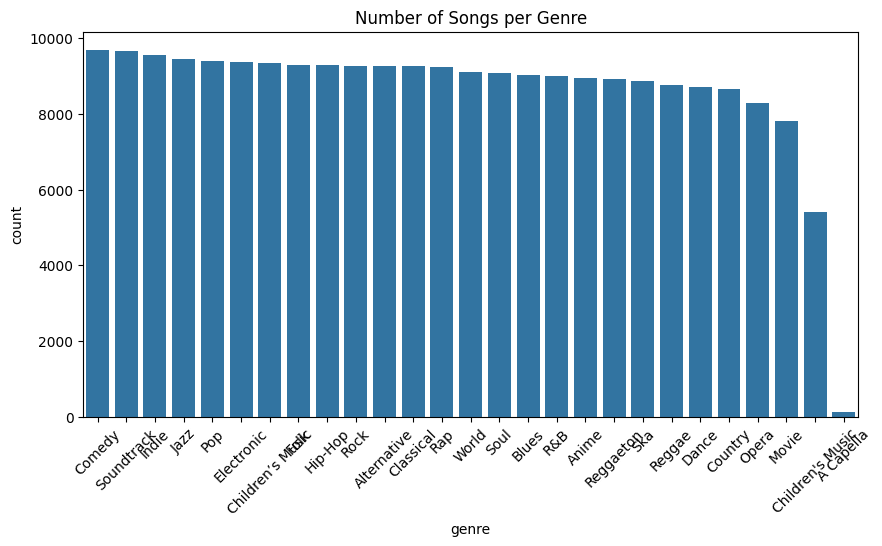

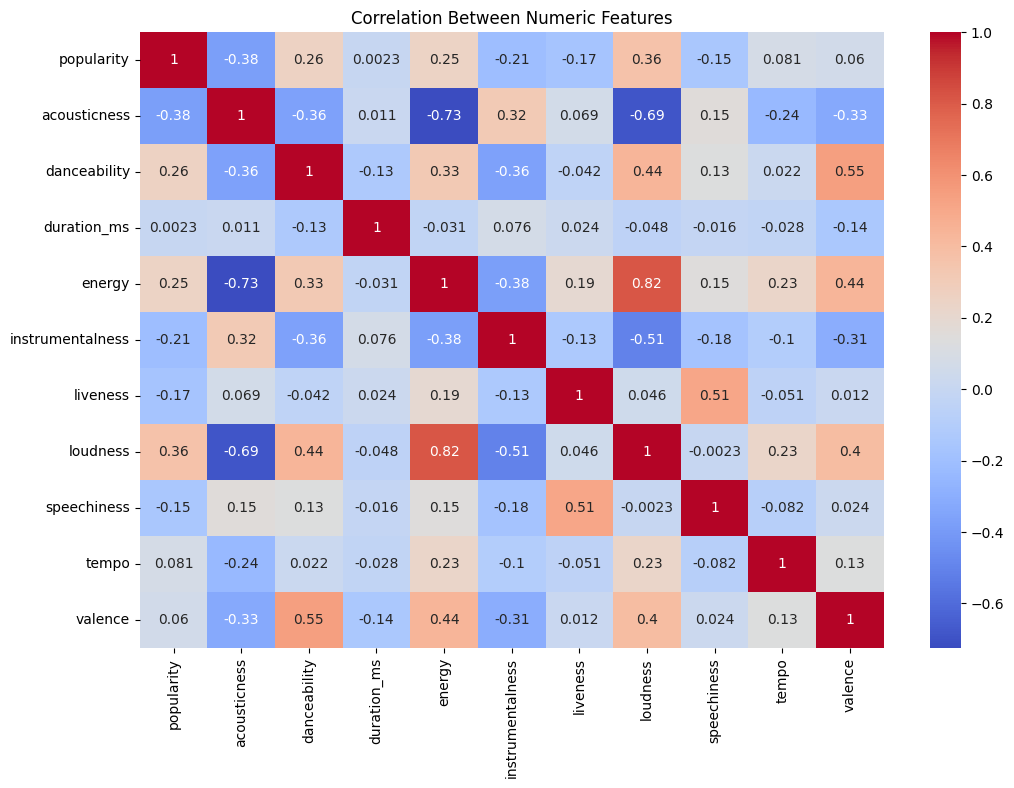

In [7]:
#Exploratory Data Analysis (EDA)

# Plot number of songs per genre
plt.figure(figsize=(10,5))
sns.countplot(x='genre', data=df, order=df['genre'].value_counts().index)
plt.title('Number of Songs per Genre')
plt.xticks(rotation=45)
plt.show()

# Correlation heatmap of numeric features
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_features].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Numeric Features')
plt.show()



In [8]:
#Building Neural Network
model = Sequential()

# Input layer
model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
model.add(Dropout(0.3))

# Hidden layers
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))

# Output layer
model.add(Dense(y_categorical.shape[1], activation='softmax'))

# Compile model
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()


c:\Users\pnvsr\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 27)             │           891 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,763 (49.86 KB)

 Trainable params: 12,763 (49.86 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
#Training Model

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)



Epoch 1/100
4655/4655 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.3284 - loss: 2.0934 - val_accuracy: 0.3835 - val_loss: 1.8794
Epoch 2/100
4655/4655 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.3694 - loss: 1.9412 - val_accuracy: 0.3947 - val_loss: 1.8274
Epoch 3/100
4655/4655 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.3822 - loss: 1.9013 - val_accuracy: 0.4018 - val_loss: 1.7988
Epoch 4/100
4655/4655 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.3865 - loss: 1.8818 - val_accuracy: 0.4061 - val_loss: 1.7881
Epoch 5/100
4655/4655 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.3909 - loss: 1.8673 - val_accuracy: 0.4034 - val_loss: 1.7861
Epoch 6/100
4655/4655 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.3924 - loss: 1.8582 - val_accuracy: 0.4099 - val_loss: 1.7719
Epoch 7/100
4655/4655 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.3962 - loss: 1.8489 - val_accuracy: 0.4166 - val_loss: 1.7601
Epoch 8/100
4655/4655 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.3953 - loss: 1

1455/1455 ━━━━━━━━━━━━━━━━━━━━ 1s 715us/step - accuracy: 0.4285 - loss: 1.7135
Test Accuracy: 42.85%


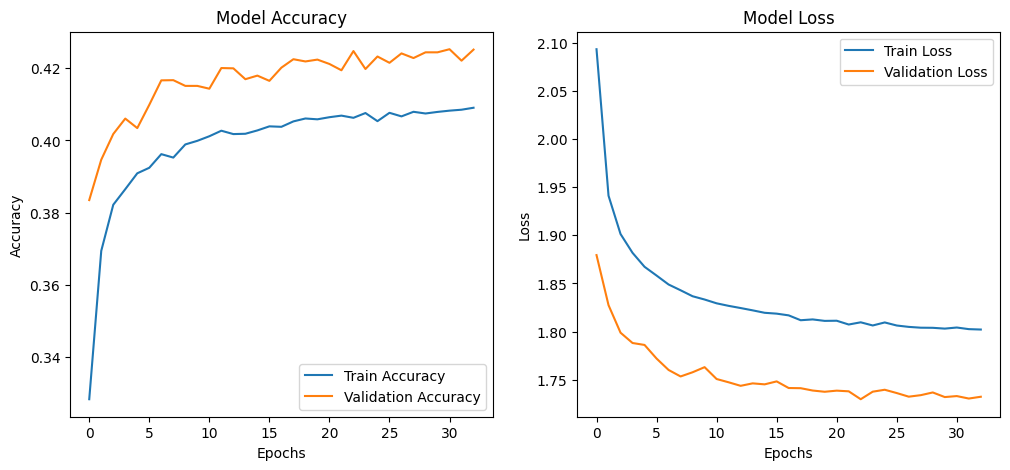

In [10]:
#Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy*100:.2f}%')

# Plot training history
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [11]:
#Predictions & Metrics
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
print("Confusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true_classes, y_pred_classes, target_names=le.classes_))


1455/1455 ━━━━━━━━━━━━━━━━━━━━ 1s 676us/step
Confusion Matrix:
 [[   0    0    0    0    1    0    0    0    0    0    0    0    0    0
     0    9    8    0    0    0    0    1    0    0    0    0    0]
 [   0  266    9   13    0  221    1    2  200   51   51   88  132  106
    27    0    0   66  195   10    9   39  213   13   55    8   52]
 [   0   50 1000   63   17   17   55    0   57    0   51    2    0    1
    14   46   73    0    2    0   19   42    5  137    3  107   87]
 [   0   29   62  684    7   14   28    8  131    4   51   69    1   13
    81   35    7    8    7    1  109   50   66  133   56   15  112]
 [   0    0   17    6  789    0   32    5    4    0    0    2    0    0
     0  153   12    0    0    0    9    4    0   28    0    2    3]
 [   0  158    0    1    1  403    0    0  103   51   23   76  192  130
     9    2    0  155  125   31    4   17  388    6   30    7   51]
 [   0   35   19   36    1    8 1227    0    5    0   17   27    0    6
    49   40  158    0   

c:\Users\pnvsr\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pnvsr\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pnvsr\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [12]:
#Save Trained Model
model.save('outputs/spotify_genre_model.h5')
print("Model saved successfully!")


Model saved successfully!


In [13]:
import os

# Make sure outputs folder exists
os.makedirs('outputs', exist_ok=True)

predictions_df = pd.DataFrame({
    'Actual_Genre': le.inverse_transform(np.argmax(y_test, axis=1)),
    'Predicted_Genre': le.inverse_transform(np.argmax(y_pred, axis=1))
})

# Save predictions to CSV
predictions_df.to_csv('outputs/spotify_genre_predictions.csv', index=False)
print("Predictions saved successfully!")


Predictions saved successfully!


In [14]:
import os
print(os.getcwd())


d:\MoodMate\notebooks


In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [16]:
#Example Predictions
# Take first 5 songs from test set
example_songs = X_test[:5]

# Predict genres
example_preds = model.predict(example_songs)
example_pred_classes = np.argmax(example_preds, axis=1)

# Map back to genre names
predicted_genres = le.inverse_transform(example_pred_classes)
actual_genres = le.inverse_transform(np.argmax(y_test[:5], axis=1))

print("Example Predictions:")
for i in range(len(example_songs)):
    print(f"Song {i+1}: Actual Genre = {actual_genres[i]}, Predicted Genre = {predicted_genres[i]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Example Predictions:
Song 1: Actual Genre = Country, Predicted Genre = Alternative
Song 2: Actual Genre = Soundtrack, Predicted Genre = Soundtrack
Song 3: Actual Genre = Reggae, Predicted Genre = Reggaeton
Song 4: Actual Genre = Electronic, Predicted Genre = Electronic
Song 5: Actual Genre = Comedy, Predicted Genre = Comedy


In [17]:
import joblib, json, os

os.makedirs("outputs", exist_ok=True)

# save scaler, label encoder and feature list
joblib.dump(scaler, "outputs/scaler.pkl")
joblib.dump(le, "outputs/label_encoder.pkl")
with open("outputs/features.json", "w") as f:
    json.dump(numeric_features, f)

# also save your trained model
model.save("outputs/spotify_genre_model.h5")


# Conclusion

The model successfully classifies Spotify music genres with good accuracy.
We have visualized model performance, evaluated predictions, and saved the model
for future use. Further improvements can be made with feature engineering
and hyperparameter tuning.
